<a href="https://colab.research.google.com/github/tzs69/BT4012-kaggle-comp/blob/main/BT4012_competition_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from google.colab import drive
# from gensim.models import Word2Vec
import pandas as pd
from scipy.sparse import csr_matrix
# from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp

In [3]:
drive.mount('/content/drive')


df_train = pd.read_csv("/content/drive/MyDrive/BT4012_competition/train.csv")
df_test = pd.read_csv("/content/drive/MyDrive/BT4012_competition/test.csv")
sample_submission = pd.read_csv("/content/drive/MyDrive/BT4012_competition/sample_submission.csv")
txs_edgelist = pd.read_csv("/content/drive/MyDrive/BT4012_competition/txs_edgelist.csv")

Mounted at /content/drive


# Dataset exploration

In [4]:
display(df_train.head())
display(df_train.describe())

,txId,time_step,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,...,feat_157,feat_158,feat_159,feat_160,feat_161,feat_162,feat_163,feat_164,feat_165,label
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,NaN
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,NaN
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,NaN
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,0.0
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,NaN


,txId,time_step,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,...,feat_157,feat_158,feat_159,feat_160,feat_161,feat_162,feat_163,feat_164,feat_165,label
count,1.417720e+05,141772.000000,141772.000000,141772.000000,141772.000000,141772.000000,141772.000000,141772.000000,141772.000000,141772.000000,...,141772.000000,141772.000000,141772.000000,141772.000000,141772.000000,141772.000000,141772.000000,141772.000000,141772.000000,31235.000000
mean,2.004880e+08,15.781903,0.018390,-0.108169,-0.300165,-0.002866,0.000438,-0.005162,0.006491,0.019083,...,-0.011303,-0.033573,-0.033653,-0.013351,-0.022239,-0.044833,-0.050354,0.027960,0.027406,0.116664
std,1.130078e+08,10.533858,1.119660,0.395017,0.961251,0.990140,1.113030,0.994618,0.956036,1.129079,...,1.022445,0.985878,0.985817,0.611416,1.087520,1.038040,0.789884,0.968482,0.968380,0.321025
min,2.534000e+03,1.000000,-0.172983,-0.210553,-1.756361,-0.121970,-0.063725,-0.113002,-0.061584,-0.163646,...,-0.626229,-0.979074,-0.978556,-0.216057,-0.125939,-0.131155,-0.269818,-1.760926,-1.760984,0.000000
25%,9.433347e+07,6.000000,-0.172436,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.163515,...,-0.594691,-0.979074,-0.978556,-0.098889,-0.087490,-0.131155,-0.140597,-0.120613,-0.119792,0.000000
50%,2.241956e+08,14.000000,-0.168768,-0.158783,-0.646376,-0.121970,-0.043875,-0.113002,-0.061584,-0.161930,...,-0.474850,0.193737,0.177509,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,0.000000
75%,2.943870e+08,24.000000,-0.135555,-0.107012,0.463609,-0.046932,-0.043875,-0.113002,-0.061584,-0.138658,...,0.048667,0.644771,0.683016,0.018279,-0.087490,-0.084674,-0.097524,0.133844,0.090311,0.000000
max,4.032446e+08,35.000000,71.681966,25.674475,2.128587,49.027598,260.090707,54.565178,113.440873,73.354565,...,7.901426,1.461330,1.461369,91.878099,251.849028,238.783493,105.734028,1.519700,1.521399,1.000000


In [5]:
display(df_test.head())
display(df_test.describe())

,index,txId,time_step,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,...,feat_156,feat_157,feat_158,feat_159,feat_160,feat_161,feat_162,feat_163,feat_164,feat_165
0,0,200459281,36,-0.172879,-0.058452,0.463609,-0.121970,-0.043875,-0.113002,-0.061584,...,2.262621,1.947206,1.461330,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,-1.760926,-1.760984
1,1,199944769,36,-0.172828,0.339970,1.018602,0.178180,-0.043875,0.222447,-0.061584,...,-0.524789,-0.531617,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,2,198827545,36,-0.172282,0.837998,1.018602,0.553368,-0.043875,0.641758,-0.061584,...,1.149152,1.070472,1.461330,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,-1.760926,-1.760984
3,3,200997190,36,-0.172926,0.156148,1.573595,-0.046932,-0.043875,-0.029140,-0.061584,...,0.125358,0.080204,1.461330,1.461369,0.018279,-0.049041,-0.038193,-0.011377,-1.760926,-1.760984
4,4,200996856,36,-0.171396,1.311640,1.573595,0.478330,-0.004174,0.474034,-0.061584,...,-0.106650,-0.137402,0.258822,0.729391,0.018279,0.393121,0.680158,0.462432,0.359796,1.091185


,index,txId,time_step,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,...,feat_156,feat_157,feat_158,feat_159,feat_160,feat_161,feat_162,feat_163,feat_164,feat_165
count,15329.000000,1.532900e+04,15329.000000,15329.000000,15329.000000,15329.000000,15329.000000,15329.000000,15329.000000,15329.000000,...,15329.000000,15329.000000,15329.000000,15329.000000,15329.000000,15329.000000,15329.000000,15329.000000,15329.000000,15329.000000
mean,7664.000000,1.027552e+08,41.907757,-0.009234,0.607044,0.858140,0.224488,0.004638,0.244128,-0.020711,...,0.038887,0.046360,0.131531,0.131762,-0.014083,0.098524,0.189584,0.149757,-0.097376,-0.096413
std,4425.245473,6.185020e+07,3.558264,0.867509,2.507116,0.743226,1.679815,0.793393,1.670688,0.534140,...,0.890907,0.880469,1.033477,1.034144,0.310495,0.937557,1.267729,0.925752,1.107991,1.107501
min,0.000000,6.418000e+03,36.000000,-0.172982,-0.210553,-1.756361,-0.121970,-0.063725,-0.113002,-0.061584,...,-0.577099,-0.626229,-0.979074,-0.978556,-0.216057,-0.125939,-0.131155,-0.269818,-1.760926,-1.760984
25%,3832.000000,6.787914e+07,39.000000,-0.172765,-0.058452,0.463609,-0.121970,-0.043875,-0.113002,-0.061584,...,-0.562153,-0.575769,-0.979074,-0.978556,-0.098889,-0.087490,-0.131155,-0.140597,-0.378297,-0.353893
50%,7664.000000,9.707855e+07,42.000000,-0.171066,0.016951,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,...,-0.285654,-0.193118,0.241128,0.241406,0.018279,-0.087490,-0.084674,-0.097524,-0.120613,-0.119792
75%,11496.000000,1.511910e+08,44.000000,-0.118738,0.221727,1.573595,0.028105,-0.043875,-0.029140,-0.061584,...,0.170195,0.206353,1.461330,1.461369,0.018279,-0.010592,0.047221,-0.005435,0.458126,0.424171
max,15328.000000,2.616356e+08,49.000000,39.786756,73.595052,2.683580,44.525348,92.556494,48.862545,36.453952,...,4.474613,7.863581,1.461330,1.461369,13.375447,89.594605,108.259475,50.223075,1.519700,1.521399


In [6]:
display(txs_edgelist.head(8))
display(txs_edgelist.shape)

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206
5,232344069,27553029
6,36411953,230405052
7,34194980,5529846


(234355, 2)

Null check

In [7]:
datasets = [df_train, df_test, txs_edgelist]
df_train.name = "df_train"
df_test.name = "df_test"
txs_edgelist.name = "txs_edgelist"

print("Null values:\n")
for dataset in datasets:
    no_nulls = True
    print(dataset.name)
    for col, count in dataset.isna().sum().items():
        if count > 0:
            no_nulls = False
            print(f" - {col}: {count}")
    if no_nulls:
        print(" - 0 null values across all columns")

Null values:

df_train
 - label: 110537
df_test
 - 0 null values across all columns
txs_edgelist
 - 0 null values across all columns


Check if train/test split is random or time based (cutoff time separating train and test data)

In [8]:
num_train_time_steps = df_train["time_step"].nunique()
num_test_time_steps = df_test["time_step"].nunique()

print(f"Train time steps ({num_train_time_steps})):")
print(sorted(df_train["time_step"].unique()))

print(f"\nTest time steps ({num_test_time_steps}):")
print(sorted(df_test["time_step"].unique()))

print("\nShared time steps:")
print(sorted(
    set(df_train["time_step"]) &
    set(df_test["time_step"])
))

Train time steps (35)):
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35)]

Test time steps (14):
[np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49)]

Shared time steps:
[]


In [9]:
labeled = df_train[df_train["label"].notna()]

print(labeled["label"].value_counts())
print(labeled["label"].value_counts(normalize=True))

label
0.0    27591
1.0     3644
Name: count, dtype: int64
label
0.0    0.883336
1.0    0.116664
Name: proportion, dtype: float64


<Axes: xlabel='time_step'>

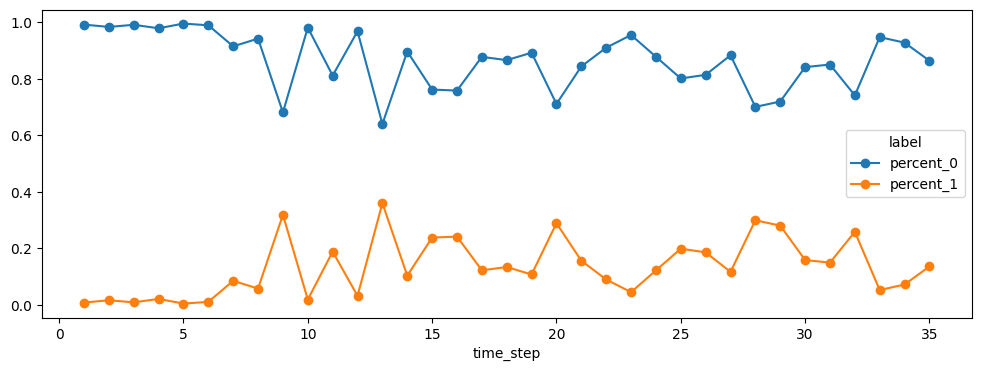

In [10]:
label_by_time = (
    labeled
    .groupby(["time_step", "label"])
    .size()
    .unstack(fill_value=0)
)

label_by_time["total"] = label_by_time.sum(axis=1)

for c in labeled["label"].dropna().unique():
    label_by_time[f"percent_{int(c)}"] = (
        label_by_time[c] / label_by_time["total"]
    )

label_by_time[[c for c in label_by_time.columns
               if str(c).startswith("percent_")]].plot(
    figsize=(12, 4),
    marker="o"
)

In [11]:
median_by_label = labeled.groupby("label").median().T.drop(["txId", "time_step"])
median_by_label["median_diff_abs"] = abs(median_by_label[1.0] - median_by_label[0.0])
display(median_by_label.sort_values(by="median_diff_abs", ascending=False).rename_axis(columns=None).head(10))

print("\n")
mean_by_label = labeled.groupby("label").mean().T.drop(["txId", "time_step"])
mean_by_label["mean_diff_abs"] = abs(mean_by_label[1.0] - mean_by_label[0.0])
display(mean_by_label.sort_values(by="mean_diff_abs", ascending=False).rename_axis(columns=None).head(10))

,0.0,1.0,median_diff_abs
feat_112,-1.096336,0.493811,1.590147
feat_53,0.770389,-0.488293,1.258682
feat_93,1.135279,0.025217,1.110062
feat_3,-0.646376,0.463609,1.109985
feat_148,-0.968903,0.117111,1.086014
feat_55,0.551675,-0.467502,1.019177
feat_92,0.998840,0.025308,0.973532
feat_89,0.146799,-0.760708,0.907507
feat_115,-0.416861,0.396719,0.813580
feat_91,0.093427,-0.719068,0.812494


,0.0,1.0,mean_diff_abs
feat_53,1.193105,-0.272626,1.465731
feat_55,0.995756,-0.239917,1.235672
feat_90,0.689032,-0.518102,1.207134
feat_54,0.999882,-0.180328,1.180210
feat_89,0.679084,-0.478488,1.157572
feat_91,0.641318,-0.345206,0.986524
feat_60,0.820402,-0.162200,0.982602
feat_66,0.820401,-0.162189,0.982589
feat_65,0.801683,-0.171890,0.973574
feat_59,0.801643,-0.171900,0.973544


Constant/near constant feature check

In [12]:
constant_feats = [col for col in df_train.columns if df_train[col].nunique() == 1]
if constant_feats:
    display(constant_feats)
else:
    print("No absolute constant features found\n")

desc = df_train.describe().drop(["txId", "time_step", "label"], axis=1)
desc = desc.T[["50%", "std"]]
desc["med_std_ratio"] = desc["50%"] / desc["std"]
desc.sort_values(by="med_std_ratio", ascending=False).head(10)

No absolute constant features found



,50%,std,med_std_ratio
feat_20,0.887058,0.991362,0.894787
feat_21,0.884557,0.990877,0.892701
feat_62,0.502421,0.992238,0.506352
feat_68,0.491571,0.992311,0.495380
feat_63,0.443354,0.992152,0.446861
feat_69,0.423447,0.992229,0.426763
feat_158,0.193737,0.985878,0.196512
feat_152,0.185597,0.964325,0.192463
feat_153,0.185492,0.964348,0.192350
feat_159,0.177509,0.985817,0.180063


No obvious near constant features found using med-to-std ratio, use value frequency w gated min threshold(0.90) to check for near constants again

In [13]:
feature_cols = [c for c in df_train.columns if c.startswith("feat_")]

near_constant_train = []
near_constant_test = []
for col in feature_cols:
    freq_train = df_train[col].value_counts(normalize=True).iloc[0]
    freq_test = df_test[col].value_counts(normalize=True).iloc[0]

    if freq_train > 0.90:
        near_constant_train.append((col, freq_train))
    if freq_test > 0.90:
        near_constant_test.append((col, freq_test))

near_constant_train = sorted(near_constant_train, key=lambda x: x[1], reverse=True)
near_constant_test = sorted(near_constant_test, key=lambda x: x[1], reverse=True)
print("Near constant features train:")
display(near_constant_train)
print("\nNear constant features test:")
display(near_constant_test)

print("\n")

for col, freq in near_constant_train:
    mode = df_train[col].mode()[0]

    tmp = labeled.copy()
    tmp["is_rare"] = tmp[col] != mode

    print("\n", col)
    print(pd.crosstab(
        tmp["is_rare"],
        tmp["label"],
        normalize="index"
    ))

Near constant features train:


[('feat_15', np.float64(0.9993087492593742)),
 ('feat_70', np.float64(0.9729213102728325)),
 ('feat_39', np.float64(0.9647885337020004)),
 ('feat_38', np.float64(0.9647744265440285)),
 ('feat_36', np.float64(0.963963264960641)),
 ('feat_7', np.float64(0.9469853003413933))]


Near constant features test:


[('feat_15', np.float64(0.9990214625872529)),
 ('feat_70', np.float64(0.9843434013960467)),
 ('feat_7', np.float64(0.9644464740035227)),
 ('feat_39', np.float64(0.9294800704546937)),
 ('feat_38', np.float64(0.9293495987996607)),
 ('feat_36', np.float64(0.9262182790788701))]




 feat_15
label         0.0       1.0
is_rare                    
False    0.883276  0.116724
True     1.000000  0.000000

 feat_70
label         0.0       1.0
is_rare                    
False    0.882094  0.117906
True     0.921589  0.078411

 feat_39
label         0.0       1.0
is_rare                    
False    0.863916  0.136084
True     0.995867  0.004133

 feat_38
label         0.0       1.0
is_rare                    
False    0.863906  0.136094
True     0.995869  0.004131

 feat_36
label         0.0       1.0
is_rare                    
False    0.863606  0.136394
True     0.995093  0.004907

 feat_7
label         0.0       1.0
is_rare                    
False    0.878014  0.121986
True     0.989290  0.010710


Check pairwise feature correlation

In [14]:
corr = df_train[feature_cols].corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = upper.stack().sort_values(ascending=False)
display(high_corr.head())

print("\nNumber of feature pairs with corr >= 0.95")
print(len(high_corr[high_corr > 0.95]))

print("\nHighest of corr value")
print(max(high_corr))

,,0
feat_24,feat_30,1.0
feat_59,feat_65,1.0
feat_23,feat_29,1.0
feat_60,feat_66,1.0
feat_61,feat_67,1.0



Number of feature pairs with corr >= 0.95
103

Highest of corr value
0.9999999949449558


### PCA

In [15]:
X = df_train[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)

for threshold in [0.80, 0.90, 0.95, 0.99]:
    n = np.argmax(cum_var >= threshold) + 1
    print(f"{threshold:.0%}: {n} PCs")

80%: 34 PCs
90%: 49 PCs
95%: 59 PCs
99%: 74 PCs


## Analyze features against time

Aggregate mean value for each feature for each time step

In [16]:
feature_mean_by_time_train = (df_train.groupby("time_step")[feature_cols].mean())
display(feature_mean_by_time_train.head())

temporal_variation_train = feature_mean_by_time_train.std().sort_values(ascending=False).rename("std")
temporal_variation_train.head(8)

,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,...,feat_156,feat_157,feat_158,feat_159,feat_160,feat_161,feat_162,feat_163,feat_164,feat_165
time_step,,,,,,,,,,,,,,,,,,,,,
1,-0.059994,-0.167240,-0.784983,0.049617,-0.003907,0.039067,0.022600,-0.065975,-0.062789,0.018526,...,0.027616,-0.022167,-0.055326,-0.054382,-0.018997,-0.037228,-0.056079,-0.071789,0.072930,0.073005
2,-0.113122,-0.164173,-0.824208,-0.020956,0.021350,-0.019284,-0.003189,-0.115841,-0.112939,0.022747,...,-0.157459,-0.140613,-0.126776,-0.127441,0.005825,-0.006070,-0.034018,-0.018682,0.073637,0.075099
3,0.237666,-0.157453,-1.012683,-0.010507,-0.028659,-0.016968,0.013514,0.247052,0.240787,-0.015531,...,-0.200553,-0.257757,-0.033524,-0.037490,0.003503,-0.057200,-0.080617,-0.057497,0.039001,0.030683
4,-0.101504,-0.157612,-0.898867,0.039836,0.011073,0.004770,0.127098,-0.099754,-0.099766,-0.004204,...,0.016933,-0.048908,0.122272,0.124557,-0.002610,0.013319,0.001560,-0.003205,-0.048545,-0.050092
5,0.051012,-0.163666,-0.840375,-0.009286,-0.020628,-0.011093,0.010297,0.051513,0.049568,-0.003722,...,0.237465,0.149213,-0.037836,-0.036818,0.011580,-0.052805,-0.073512,-0.043683,0.048855,0.050551


,std
feat_101,0.672220
feat_103,0.671761
feat_100,0.668144
feat_136,0.610983
feat_139,0.603796
feat_137,0.544513
feat_3,0.431902
feat_115,0.431489


Check train feature correlation w time

,time_corr
feat_101,0.991907
feat_103,0.987947
feat_100,0.961774
feat_136,0.845566
feat_139,0.807630
feat_137,0.646650
feat_151,0.445321
feat_3,0.437311


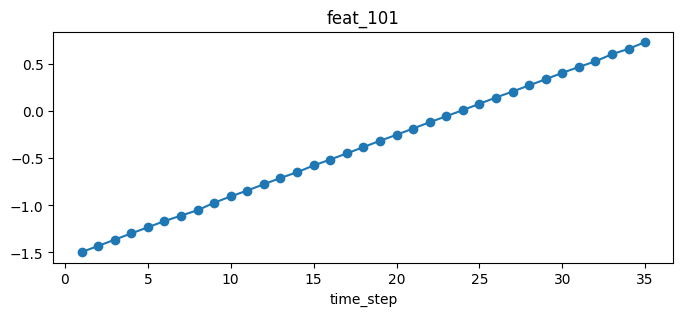

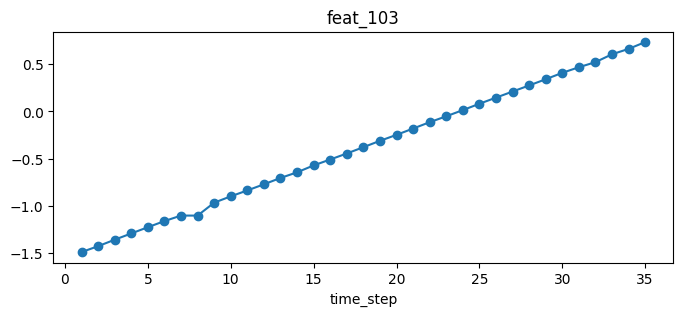

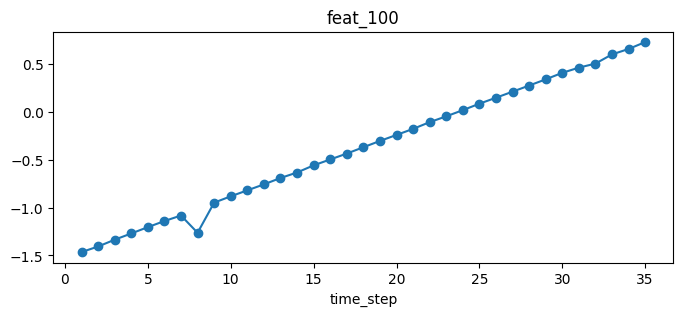

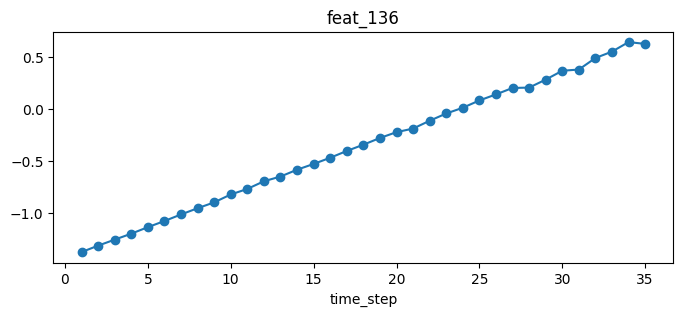

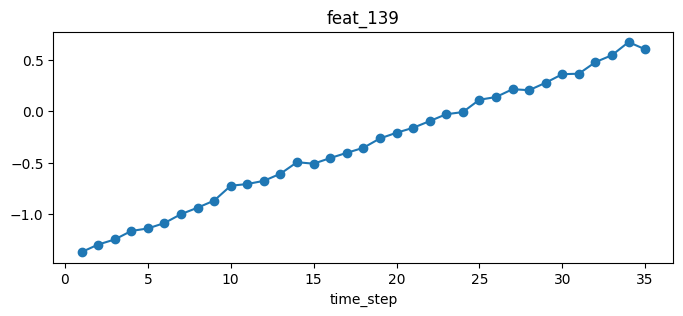

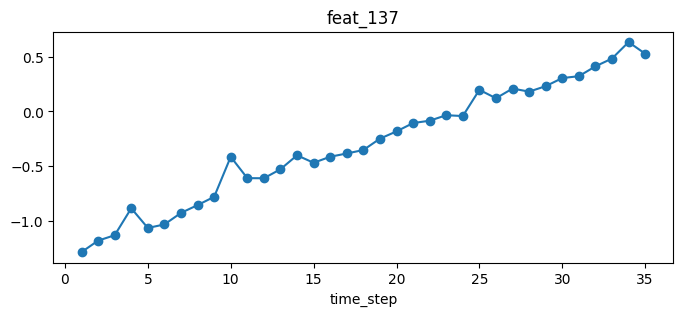

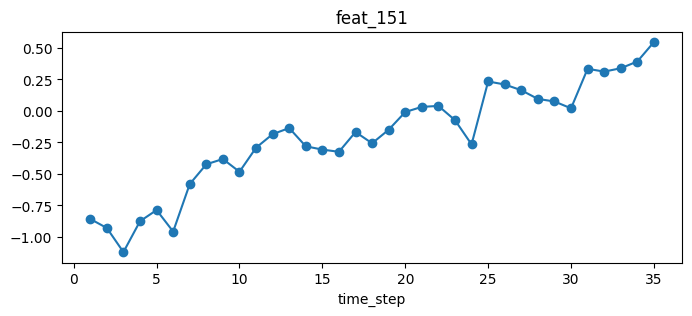

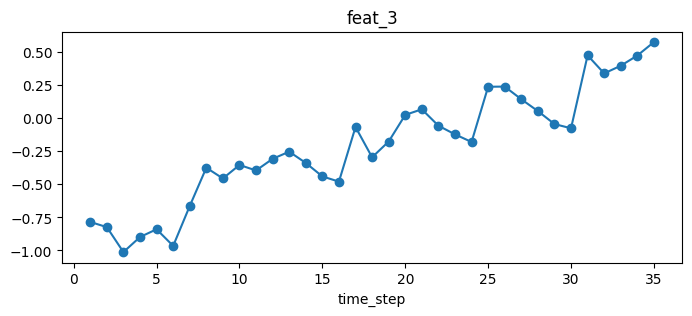

In [17]:
time_corr_train = (
    df_train[feature_cols]
    .corrwith(df_train["time_step"])
    .abs()
    .sort_values(ascending=False)
    .rename("time_corr")
)

display(time_corr_train.head(8))

for col in time_corr_train.head(8).index:
    plt.figure(figsize=(8, 3))
    feature_mean_by_time_train[col].plot(marker="o")
    plt.title(col)
    plt.show()

In [18]:
feature_mean_by_time_test = df_test.groupby("time_step")[feature_cols].mean()
display(feature_mean_by_time_test.head())

temporal_variation_test = feature_mean_by_time_test.std().sort_values(ascending=False).rename("std")
temporal_variation_test.head(8)

,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,...,feat_156,feat_157,feat_158,feat_159,feat_160,feat_161,feat_162,feat_163,feat_164,feat_165
time_step,,,,,,,,,,,,,,,,,,,,,
36,0.060301,0.482864,0.619904,0.239291,-0.007452,0.258535,-0.028090,0.053723,0.063600,0.059440,...,-0.008694,-0.015470,0.183649,0.180074,-0.027820,0.093037,0.187599,0.131833,-0.120811,-0.121173
37,0.105642,0.503955,0.732190,0.373157,-0.001783,0.409369,-0.045697,0.073145,0.098247,0.230953,...,0.192238,0.155968,0.008119,0.009260,-0.032541,-0.033793,-0.049789,-0.072578,0.015743,0.006275
38,-0.074717,0.310311,0.708070,0.194955,-0.017697,0.185729,0.026968,-0.089852,-0.082916,0.017519,...,-0.063211,-0.032257,0.130626,0.132719,-0.011168,-0.023281,-0.005768,-0.010242,-0.043195,-0.049693
39,0.190040,0.294867,0.792476,0.013199,-0.019897,0.027146,-0.034061,0.188383,0.185626,-0.008133,...,-0.132760,-0.146412,0.148218,0.147871,-0.025201,-0.042053,-0.049914,-0.062429,0.012366,0.009698
40,-0.073821,0.918267,0.978730,0.464946,-0.001404,0.430267,0.023850,-0.107271,-0.081333,0.133738,...,-0.011535,0.027938,0.189773,0.188123,-0.016261,0.075592,0.166758,0.140376,-0.048330,-0.044502


,std
feat_109,0.800893
feat_106,0.776800
feat_107,0.770442
feat_85,0.511590
feat_46,0.505176
feat_124,0.504018
feat_84,0.501709
feat_49,0.500737


Check test feature correlation w time

,time_corr
feat_101,0.939706
feat_103,0.932432
feat_100,0.911477
feat_136,0.390196
feat_139,0.364887
feat_137,0.303288
feat_106,0.192919
feat_109,0.188237


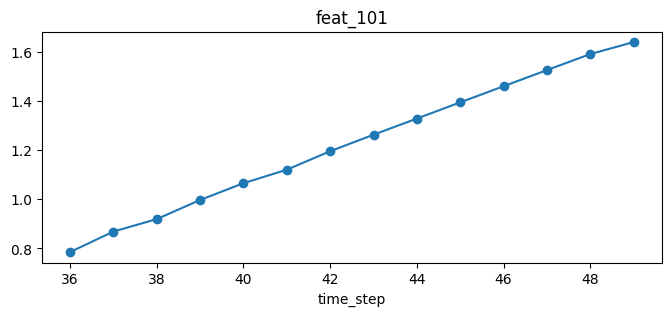

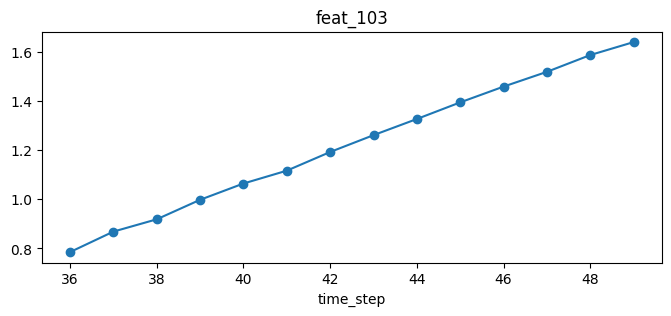

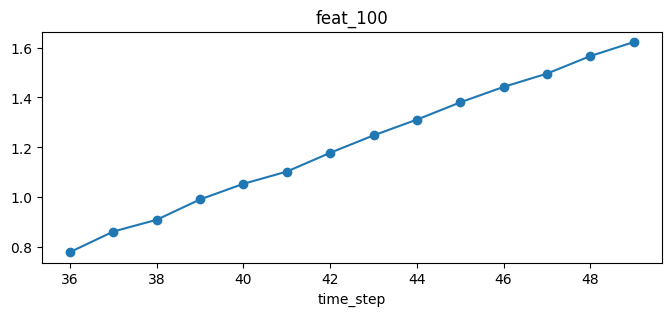

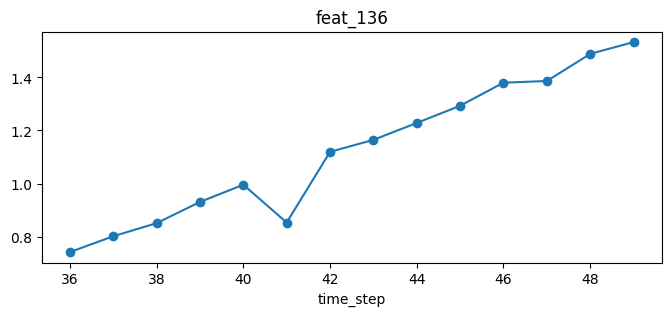

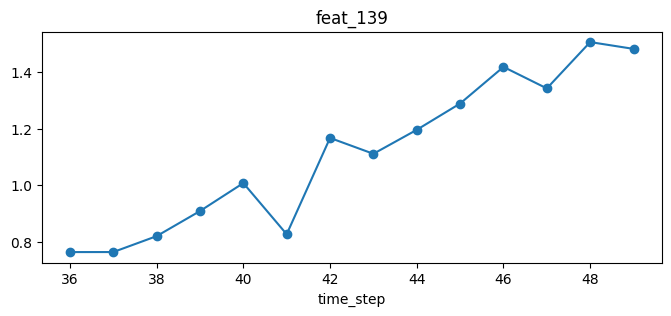

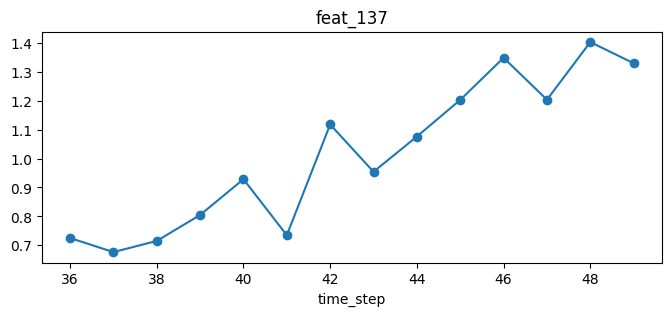

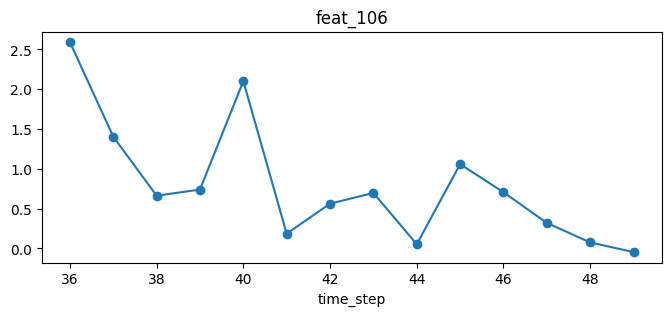

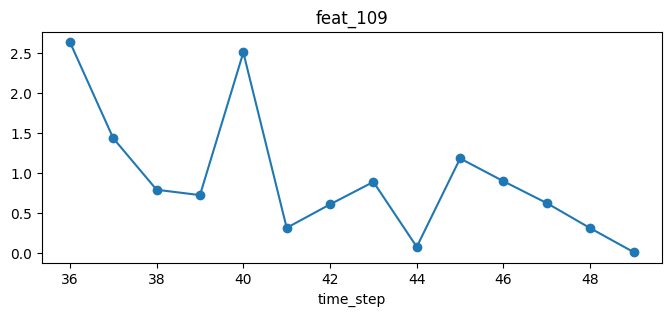

In [19]:
time_corr_test = (
    df_test[feature_cols]
    .corrwith(df_test["time_step"])
    .abs()
    .sort_values(ascending=False)
    .rename("time_corr")
)

display(time_corr_test.head(8))

for col in time_corr_test.head(8).index:
    plt.figure(figsize=(8, 3))
    feature_mean_by_time_test[col].plot(marker="o")
    plt.title(col)
    plt.show()

Check train vs test range drift/overlap for all features (additional verification for correlation w time since train/test split is on a temporal basis)

In [20]:
compare = []

for col in feature_cols:
    train_min = df_train[col].min()
    train_max = df_train[col].max()

    below = (df_test[col] < train_min).mean()
    above = (df_test[col] > train_max).mean()

    compare.append({
        "feature": col,
        "test_below_train_min": below,
        "test_above_train_max": above,
        "outside_train_range": below + above
    })

range_compare = pd.DataFrame(compare).sort_values("outside_train_range", ascending=False)
display(range_compare.head(20))

,feature,test_below_train_min,test_above_train_max,outside_train_range
100,feat_101,0.0,0.995433,0.995433
102,feat_103,0.0,0.994259,0.994259
99,feat_100,0.0,0.992106,0.992106
106,feat_107,0.0,0.019897,0.019897
108,feat_109,0.0,0.011351,0.011351
105,feat_106,0.0,0.010829,0.010829
107,feat_108,0.0,0.003849,0.003849
112,feat_113,0.0,0.003392,0.003392
144,feat_145,0.0,0.001109,0.001109
114,feat_115,0.0,0.001109,0.001109


KS 2 sample test to check which feature share similar distributions in both training and testing data (lower ks_stat more similarity b/w 2 distributions)

In [21]:
ks_results = []

for col in feature_cols:
    stat, _ = ks_2samp(df_train[col], df_test[col])
    ks_results.append({"feature": col, "ks_stat": stat})

ks_results = pd.DataFrame(ks_results)

print("Most similar distribution features across train test split:")
display(ks_results.sort_values("ks_stat", ascending=True).head(13))

print("\nLeast similar distribution features across train test split:")
display(ks_results.sort_values("ks_stat", ascending=False).head(13))

[('feat_15', np.float64(0.9993087492593742)),
 ('feat_70', np.float64(0.9729213102728325)),
 ('feat_39', np.float64(0.9647885337020004)),
 ('feat_38', np.float64(0.9647744265440285)),
 ('feat_36', np.float64(0.963963264960641)),
 ('feat_7', np.float64(0.9469853003413933))]

Most similar distribution features across train test split:


,feature,ks_stat
14,feat_15,0.000287
69,feat_70,0.011482
159,feat_160,0.017165
6,feat_7,0.017461
38,feat_39,0.022826
37,feat_38,0.023475
74,feat_75,0.023590
73,feat_74,0.024708
103,feat_104,0.028622
134,feat_135,0.029613



Least similar distribution features across train test split:


,feature,ks_stat
135,feat_136,0.996100
100,feat_101,0.995433
102,feat_103,0.994259
99,feat_100,0.992106
138,feat_139,0.965543
136,feat_137,0.928830
1,feat_2,0.664172
108,feat_109,0.647763
106,feat_107,0.631840
105,feat_106,0.550014


[('feat_15', np.float64(0.9993087492593742)),
 ('feat_70', np.float64(0.9729213102728325)),
 ('feat_39', np.float64(0.9647885337020004)),
 ('feat_38', np.float64(0.9647744265440285)),
 ('feat_36', np.float64(0.963963264960641)),
 ('feat_7', np.float64(0.9469853003413933))]

Univariate AUC on all feature columns to discern which individual features have strong standalone predictive power

In [22]:
auc_results = []

for col in feature_cols:
    auc = roc_auc_score(labeled["label"], labeled[col])
    auc = max(auc, 1 - auc)

    if auc >= 0.80:
        auc_results.append({"feature": col, "auc": auc})

if not auc_results:
    print("No features with AUC >= 0.80")
else:
    auc_results = pd.DataFrame(auc_results).sort_values("auc", ascending=False)
    display(auc_results)

,feature,auc
6,feat_53,0.856809
7,feat_55,0.839660
10,feat_90,0.836702
0,feat_5,0.817001
1,feat_14,0.816922
9,feat_66,0.816405
8,feat_60,0.816392
3,feat_29,0.813166
2,feat_23,0.813159
11,feat_132,0.810787


## Transaction Graph Analysis

For all edges where both transactions have known time steps, the time step for both transactions are equal

In [23]:
all_nodes = pd.concat([
    df_train[["txId", "time_step"]],
    df_test[["txId", "time_step"]]
])

time_map = all_nodes.set_index("txId")["time_step"]

edges = txs_edgelist.copy()

edges["time_1"] = edges["txId1"].map(time_map)
edges["time_2"] = edges["txId2"].map(time_map)

edges["both_times_known"] = (edges["time_1"].notna() & edges["time_2"].notna())
print(edges["both_times_known"].value_counts(normalize=True))

print("\n")
edges["same_time_step"] = (edges["time_1"] == edges["time_2"])
print(edges["same_time_step"].value_counts(normalize=True))

print("\n")
(edges["both_times_known"] == edges["same_time_step"]).value_counts(normalize=True)

both_times_known
True     0.750648
False    0.249352
Name: proportion, dtype: float64


same_time_step
True     0.750648
False    0.249352
Name: proportion, dtype: float64




,proportion
True,1.0


In [24]:
train_test_all_txn_ids = set(all_nodes["txId"])
edge_list_all_txn_ids = (set(txs_edgelist["txId1"]) | set(txs_edgelist["txId2"]))

print("Num train/test transactions:", len(train_test_all_txn_ids))
print("Num edge list transactions:", len(edge_list_all_txn_ids))
print("Edge list transactions without corresponding train/test row:", len(edge_list_all_txn_ids - train_test_all_txn_ids))
print("Train/test transactions absent from edge list:", len(train_test_all_txn_ids - edge_list_all_txn_ids))

Num train/test transactions: 157101
Num edge list transactions: 203769
Edge list transactions without corresponding train/test row: 46668
Train/test transactions absent from edge list: 0


,in_degree,out_degree,total_degree
1076,1.0,1.0,2.0
3181,1.0,112.0,113.0
3321,1.0,0.0,1.0
5473,1.0,28.0,29.0
6415,1.0,1.0,2.0
6418,97.0,2.0,99.0
7952,1.0,99.0,100.0
9334,1.0,0.0,1.0
9351,1.0,0.0,1.0
9363,1.0,0.0,1.0


,in_degree,out_degree,total_degree
count,203769.000000,203769.000000,203769.000000
mean,1.150101,1.150101,2.300203
std,3.911132,1.894740,4.328377
min,0.000000,0.000000,1.000000
25%,0.000000,1.000000,1.000000
50%,1.000000,1.000000,2.000000
75%,1.000000,1.000000,2.000000
max,284.000000,472.000000,473.000000


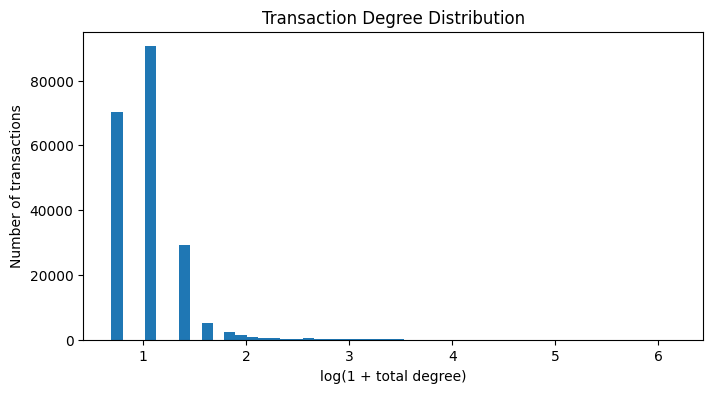

In [25]:
in_degree = (txs_edgelist.groupby("txId2").count()).rename(columns={"txId1": "in_degree"})
out_degree = (txs_edgelist.groupby("txId1").count()).rename(columns={"txId2": "out_degree"})

degree = pd.concat([in_degree, out_degree], axis=1).fillna(0)

degree["total_degree"] = (degree["in_degree"] + degree["out_degree"])

display(degree.head(20))
print("\n")
display(degree.describe())
print("\n")
print("\n")

plt.figure(figsize=(8, 4))
plt.hist(np.log1p(degree["total_degree"]), bins=50)

plt.xlabel("log(1 + total degree)")
plt.ylabel("Number of transactions")
plt.title("Transaction Degree Distribution")
plt.show()

Merge degree with train/test data for feature-degree correlation check

In [26]:
df_train_merged = df_train.merge(degree, left_on="txId", right_index=True, how="left")

total_degree_corr_train = (
    df_train_merged[feature_cols]
    .corrwith(df_train_merged["total_degree"])
    .abs()
    .sort_values(ascending=False)
    .rename("total_degree_corr")
)

in_degree_corr_train = (
    df_train_merged[feature_cols]
    .corrwith(df_train_merged["in_degree"])
    .abs()
    .sort_values(ascending=False)
    .rename("in_degree_corr")
)

out_degree_corr_train = (
    df_train_merged[feature_cols]
    .corrwith(df_train_merged["out_degree"])
    .abs()
    .sort_values(ascending=False)
    .rename("out_degree_corr")
)

display(total_degree_corr_train.head())
display(in_degree_corr_train.head())
display(out_degree_corr_train.head())

,total_degree_corr
feat_6,0.458965
feat_4,0.448759
feat_2,0.355172
feat_14,0.312197
feat_5,0.308608


,in_degree_corr
feat_6,0.513859
feat_4,0.504174
feat_2,0.358701
feat_114,0.158431
feat_119,0.154913


,out_degree_corr
feat_14,0.651012
feat_5,0.643691
feat_143,0.141734
feat_161,0.127932
feat_89,0.100140


In [27]:
df_test_merged = df_test.merge(degree, left_on="txId", right_index=True, how="left")

total_degree_corr_test = (
    df_test_merged[feature_cols]
    .corrwith(df_test_merged["total_degree"])
    .abs()
    .sort_values(ascending=False)
    .rename("total_degree_corr")
)

in_degree_corr_test = (
    df_test_merged[feature_cols]
    .corrwith(df_test_merged["in_degree"])
    .abs()
    .sort_values(ascending=False)
    .rename("in_degree_corr")
)

out_degree_corr_test = (
    df_test_merged[feature_cols]
    .corrwith(df_test_merged["out_degree"])
    .abs()
    .sort_values(ascending=False)
    .rename("out_degree_corr")
)

display(total_degree_corr_test.head())
display(in_degree_corr_test.head())
display(out_degree_corr_test.head())

,total_degree_corr
feat_6,0.618259
feat_2,0.608384
feat_4,0.573362
feat_119,0.316911
feat_35,0.286498


,in_degree_corr
feat_6,0.620990
feat_2,0.594963
feat_4,0.576688
feat_119,0.297934
feat_76,0.235090


,out_degree_corr
feat_5,0.578970
feat_14,0.578843
feat_35,0.460811
feat_23,0.429262
feat_29,0.429185


Total degree by label

In [28]:
labeled_graph = labeled.merge(degree, left_on="txId", right_index=True, how="left")
labeled_graph[["label", "in_degree", "out_degree", "total_degree"]].groupby("label").agg(["mean", "median", "std"])

in_degree                  out_degree                  total_degree  \
           mean median       std       mean median       std         mean   
label                                                                       
0.0    1.830379    1.0  6.115934   1.148382    1.0  3.781589     2.978761   
1.0    1.254391    1.0  7.225918   0.754665    1.0  0.555132     2.009056   

                        
      median       std  
label                   
0.0      2.0  7.085993  
1.0      1.0  7.189385

Rate of illicit transactions for each degree bin (check for total_degree and also in_degree, out_degree)

In [29]:
degree_bin_labels = ["1", "2", "3", "4-5", "6-10", "11-20", "21-50", "50+"]
degree_bin_values = [0, 1, 2, 3, 5, 10, 20, 50, np.inf]

degrees = ["total_degree", "in_degree", "out_degree"]
for degree in degrees:
    labeled_graph[f"{degree}_bin"] = pd.cut(
        labeled_graph[degree],
        bins=degree_bin_values,
        labels=degree_bin_labels
    )

for degree in degrees:
    display(
        labeled_graph
        .groupby(f"{degree}_bin", observed=True)["label"]
        .agg(count="count", illicit_rate="mean")
    )
    print("\n")

,count,illicit_rate
total_degree_bin,,
1,12148,0.157145
2,10769,0.139474
3,4367,0.038470
4-5,1829,0.020776
6-10,1108,0.006318
11-20,599,0.003339
21-50,333,0.009009
50+,82,0.182927


,count,illicit_rate
in_degree_bin,,
1,15117,0.171264
2,3442,0.016270
3,667,0.031484
4-5,708,0.031073
6-10,814,0.003686
11-20,418,0.004785
21-50,291,0.010309
50+,75,0.200000


,count,illicit_rate
out_degree_bin,,
1,16153,0.142512
2,5700,0.039298
3,486,0.000000
4-5,303,0.000000
6-10,174,0.000000
11-20,69,0.000000
21-50,23,0.000000
50+,7,0.000000


Graph label homophily check: determine if graph edges carry any label signal between transaction source and transaction dest

In [35]:
label_map = labeled.set_index("txId")["label"]

labeled_edges = txs_edgelist.copy()

labeled_edges["src_label"] = labeled_edges["txId1"].map(label_map)
labeled_edges["dst_label"] = labeled_edges["txId2"].map(label_map)

src_labeled_only = labeled_edges.dropna(subset=["src_label"])
dst_labeled_only = labeled_edges.dropna(subset=["dst_label"])
both_labeled = labeled_edges.dropna(subset=["src_label", "dst_label"])

print("Edges with both src and dest transactions labelled:")
display(pd.crosstab(both_labeled["src_label"], both_labeled["dst_label"], normalize="index"))

print("\n")
print("\nEdges with src transaction labelled only:")
display(pd.crosstab(src_labeled_only["src_label"], columns="no_label", normalize=True))

print("\n")
print("\nEdges with dest transaction labelled only:")
display(pd.crosstab(dst_labeled_only["dst_label"], columns="no_label", normalize=True))

Edges with both src and dest transactions labelled:


dst_label,0.0,1.0
src_label,,
0.0,0.973311,0.026689
1.0,0.440235,0.559765





Edges with src transaction labelled only:


col_0,no_label
src_label,
0.0,0.920139
1.0,0.079861





Edges with dest transaction labelled only:


col_0,no_label
dst_label,
0.0,0.917001
1.0,0.082999
